In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set the default text font size
plt.rc('font', size=15)
# Set the axes title font size
plt.rc('axes', titlesize=16)
# Set the axes labels font size
plt.rc('axes', labelsize=15)
# Set the font size for x tick labels
plt.rc('xtick', labelsize=13)
# Set the font size for y tick labels
plt.rc('ytick', labelsize=13)
# Set the legend font size
plt.rc('legend', fontsize=13)
# Set the font size of the figure title
plt.rc('figure', titlesize=17)

## Data


### Skill by NWP

In [65]:
skill_nwp = pd.read_csv('../../results/skill/NWP/leadtime_ranges/window_1/kge_0.5/skill_by_criteria.csv')
skill_nwp = skill_nwp.loc[skill_nwp.OF.isin([np.nan, 'f0.8'])]
# skill_nwp.leadtime = skill_nwp.leadtime.replace({12: '12-48', 60: '60-132', 144: '144-168', 180: '180-240'})

mask_baseline = (skill_nwp.OF == 'f0.8') & (skill_nwp.model == 'EUE')
mask_nwp = skill_nwp.OF == 'f0.8'

### Skill by approach

In [66]:
skill_app = pd.read_csv('../../results/skill/leadtime_ranges/window_1/kge_0.5/skill_by_criteria.csv')
skill_app = skill_app.loc[skill_app.OF.isin([np.nan, 'f0.8'])]

mask_benchmark = (skill_app.OF.isnull()) & (skill_app.approach == '1D+1P')
mask_app = skill_app.OF == 'f0.8'

## Analysis

### Skill by NWP

In [67]:
leadtimes = ['12-48', '60-132', '144-168', '180-240']
order_nwp = ['current', 'EUE', 'COS', 'EUD', 'DWD']

In [68]:
results_nwp = {}
for col in ['f0.8', 'recall', 'precision', 'probability', 'persistence']:
    df = pd.pivot_table(skill_nwp.loc[mask_nwp, ['model', 'leadtime', col]], index='model', columns='leadtime', aggfunc=lambda x: x)
    # df.rename(columns=map_leadtimes, inplace=True)
    df.columns = leadtimes
    df.loc['current'] = skill_app.loc[mask_benchmark, col].values
    if col == 'probability':
        df.replace(0.05, np.nan, inplace=True)
    elif col == 'persistence':
        df.replace(['1/1', np.nan], '', inplace=True)
    results_nwp[col] = df.loc[order_nwp]

In [69]:
from copy import deepcopy

In [70]:
results_nwp_ = deepcopy(results_nwp)
for key, df in results_nwp_.items():
    df.loc[['EUE', 'COS', 'EUD', 'DWD']] = np.nan

In [79]:
def barplot_skill(results, save=None, **kwargs):
    """
    """
    
    fig, ax = plt.subplots(figsize=kwargs.get('figsize', (6, 6)))

    X = np.array([1., 3.75, 6.25, 8.5])
    w = kwargs.get('width', .35)
    colors = kwargs.get('colors', ['gray', 'orange', '#295D8A', 'steelblue', 'lightsteelblue'])
    
    shift = results['f0.8'].shape[0] / 2
    for i, (idx, c) in enumerate(zip(results['f0.8'].index, colors)):
        ax.bar(X + (i - shift) * w, results['f0.8'].loc[idx].values, width=w, color=c, alpha=.6, label=idx, align='edge')
        ax.scatter(X + (i - (shift - .5)) * w, results['probability'].loc[idx].values, color=c)
        for x, col in zip(X, results['f0.8'].columns):
            M = np.max([results[var].loc[idx, col] for var in ['precision', 'recall']])
            m = np.min([results[var].loc[idx, col] for var in ['precision', 'recall']])
            ax.vlines(x + (i - (shift - .5)) * w, results['f0.8'].loc[idx, col], M, color=c, linestyle=':', zorder=0)
            ax.vlines(x + (i - (shift - .5)) * w, m, results['f0.8'].loc[idx, col], color=c, linestyle='-', zorder=0)
            # ax.text(x + (i - (shift - .5)) * w, skill.loc[idx, col] + .01, persistence.loc[idx, col], rotation=90, color=c, fontsize=12,
            #         horizontalalignment='center', verticalalignment='bottom')
            ax.text(x + (i - (shift - .05)) * w, .01, results['persistence'].loc[idx, col], rotation=90, color='w', fontsize=12,
                    horizontalalignment='left', verticalalignment='bottom')

    ax.set(xlabel='leadtime (h)', xlim=(0, 9.5), ylabel='skill | probability', ylim=(0, 1))
    ax.set_xticks(X)
    ax.set_xticklabels(results['f0.8'].columns)
    fig.legend(bbox_to_anchor=[.93, .4, .21, 0.2])#[.93, .9, .2, 0])
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.axvline(2, color='k', ls=':', lw=.8);

    if save is not None:
        plt.savefig(save, dpi=300, bbox_inches='tight')

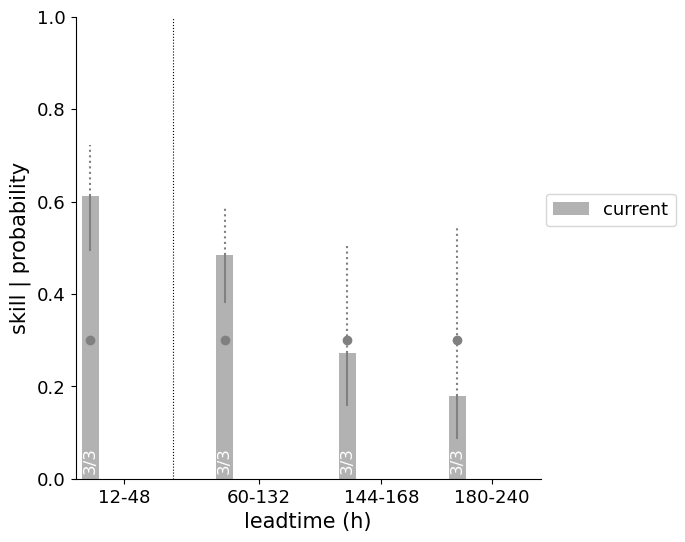

In [80]:
barplot_skill(results_nwp_, colors=['gray'],#, 'steelblue', 'lightsteelblue', 'khaki', 'orange'],
              save='skill_current.jpg')

C:\DEV\Anaconda3\envs\xr\lib\site-packages\numpy\core\_asarray.py:102: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


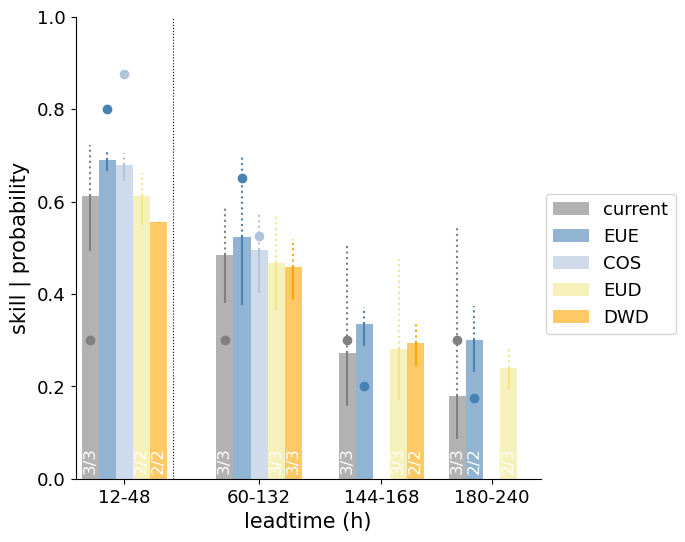

In [81]:
barplot_skill(results_nwp, colors=['gray', 'steelblue', 'lightsteelblue', 'khaki', 'orange'],
              save='skill_nwp_vs_current.jpg')

### Skill by approach

In [83]:
order_app = ['EUE', '1D+1P', 'MM', 'MW', 'BW']

results_app = {}
for col in ['f0.8', 'recall', 'precision', 'probability', 'persistence']:
    df = pd.pivot_table(skill_app.loc[mask_app, ['approach', 'leadtime', col]], index='approach', columns='leadtime', aggfunc=lambda x: x)
    df.columns = leadtimes
    df.loc['EUE'] = skill_nwp.loc[mask_baseline, col].values
    if col == 'probability':
        df.replace(0.05, np.nan, inplace=True)
    elif col == 'persistence':
        df.replace(['1/1', np.nan], '', inplace=True)
    results_app[col] = df.loc[order_app]

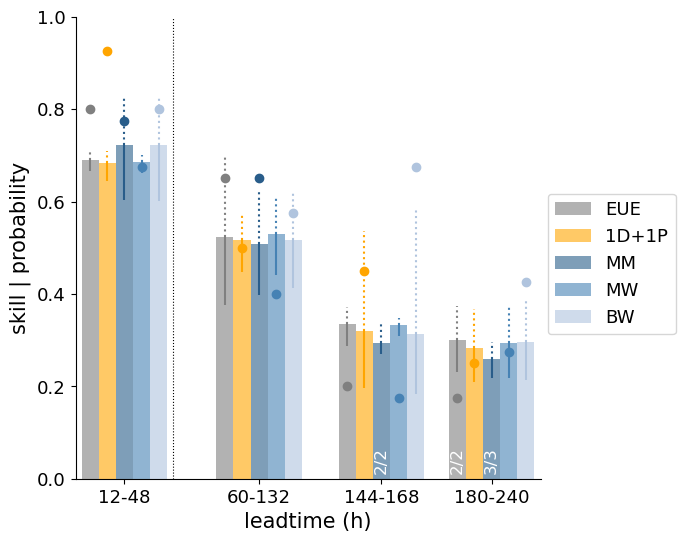

In [84]:
barplot_skill(results_app, save='skill_approach_vs_baseline.jpg')

In [82]:
results_app_ = deepcopy(results_app)
for key, df in results_app_.items():
    df.loc[['1D+1P', 'MM', 'MW', 'BW']] = np.nan

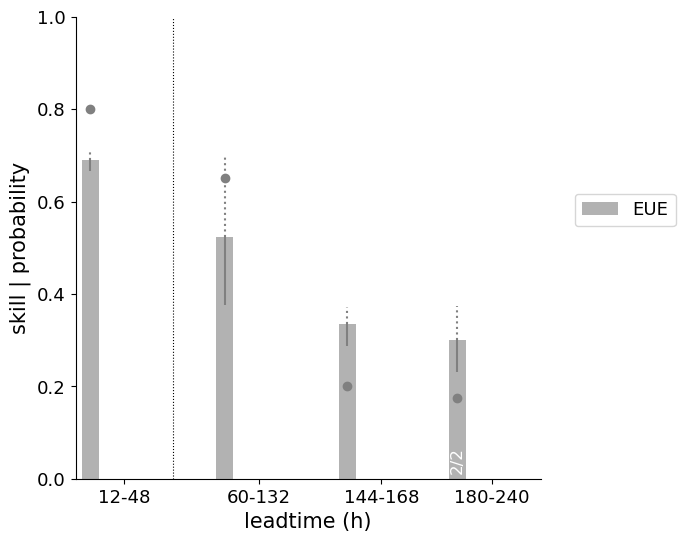

In [86]:
barplot_skill(results_app_, colors=['gray'], save='skill_baseline.jpg')

In [12]:
point = pd.read_parquet('../../results/skill/leadtime_ranges/window_1/kge_0.5/f0.8/reporting_points_over_500km2.parquet')
point.head()

,name,X,Y,area,subcatchment,river,catchment,country,KGE,correlation,...,rl100,rl200,rl500,n_events_obs,TP,FN,FP,recall,precision,f0.8
id,,,,,,,,,,,,,,,,,,,,,
1,Schwabelweis,4477500,2882500,35525,Danube,Danube,Danube,DE,0.861,0.874,...,3278.7,3557.8,3926.1,0,0.0,0.0,0.0,NaN,NaN,NaN
2,Hofkirchen,4547500,2847500,47525,Danube,Danube,Danube,DE,0.844,0.878,...,4350.0,4718.7,5205.0,0,0.0,0.0,0.0,NaN,NaN,NaN
3,Pfelling,4517500,2867500,37725,Danube,Danube,Danube,DE,NaN,NaN,...,3375.7,3664.7,4045.9,0,0.0,0.0,0.0,NaN,NaN,NaN
4,Barby,4452500,3207500,93975,"Elbe, below Saale",Elbe,Elbe,DE,0.613,0.653,...,6150.0,6858.7,7793.8,0,0.0,0.0,0.0,NaN,NaN,NaN
5,Wittenberg / Lutherstadt,4497500,3197500,61675,Elbe,Elbe,Elbe,DE,0.692,0.753,...,4785.7,5348.1,6090.0,0,0.0,0.0,0.0,NaN,NaN,NaN


In [14]:
point.to_csv('../../results/skill/leadtime_ranges/window_1/kge_0.5/f0.8/reporting_points_over_500km2.csv')